In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")

df = pd.read_csv('dataset/advertising.csv')

X = df.drop(columns = ['Sales'])
y = df['Sales']

print(f"Data Shape: {df.shape}")
print("--- Columns ---")
print(X.columns.tolist())
print("\n--- Data Types ---")
print(df.dtypes)


Data Shape: (200, 4)
--- Columns ---
['TV', 'Radio', 'Newspaper']

--- Data Types ---
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Training Features: {X_train_scaled.shape}")
print(f"Testing Features:  {X_test_scaled.shape}")


Training Features: (160, 3)
Testing Features:  (40, 3)


In [5]:
X_train_sm = sm.add_constant(X_train_scaled)

ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     468.7
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           8.51e-78
Time:                        22:09:43   Log-Likelihood:                -305.78
No. Observations:                 160   AIC:                             619.6
Df Residuals:                     156   BIC:                             631.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.3306      0.131    117.049      0.0

## OLS Summary Interpretation
Based on the standard `statsmodels` output, we can draw a few critical insights:
1. **Model Fit**: The $R^2$ value is approximately 0.90, meaning our features explain about 90% of the target's variance.
2. **Statistical Significance (p-values)**: Both `TV` and `Radio` have p-values close to 0.000, confirming they are highly statistically significant predictors. `Newspaper`, however, has a high p-value (well above 0.05), proving statistically what we suspected from EDA: it adds almost no predictive power.



In [7]:
def evaluate_model(true, pred):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return [mae, mse, rmse, r2]

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}


results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_metrics = evaluate_model(y_train, y_train_pred)
    test_metrics = evaluate_model(y_test, y_test_pred)
    
    results.append({
        "Model": name,
        "Train R2": train_metrics[3],
        "Test R2": test_metrics[3],
        "Test MAE": test_metrics[0],
        "Test RMSE": test_metrics[2]
    })

results_df = pd.DataFrame(results).round(4).set_index("Model")
print("--- Model Performance Comparison ---")
display(results_df)

lasso_coefs = pd.Series(models["Lasso Regression"].coef_, index=X.columns)
print("\n--- Lasso Coefficients ---")
print(lasso_coefs)


--- Model Performance Comparison ---


,Train R2,Test R2,Test MAE,Test RMSE
Model,,,,
Linear Regression,0.9001,0.9059,1.2748,1.7052
Ridge Regression,0.9001,0.9057,1.2734,1.7074
Lasso Regression,0.8993,0.9052,1.2701,1.7118



--- Lasso Coefficients ---
TV           4.492181
Radio        1.423016
Newspaper    0.015662
dtype: float64


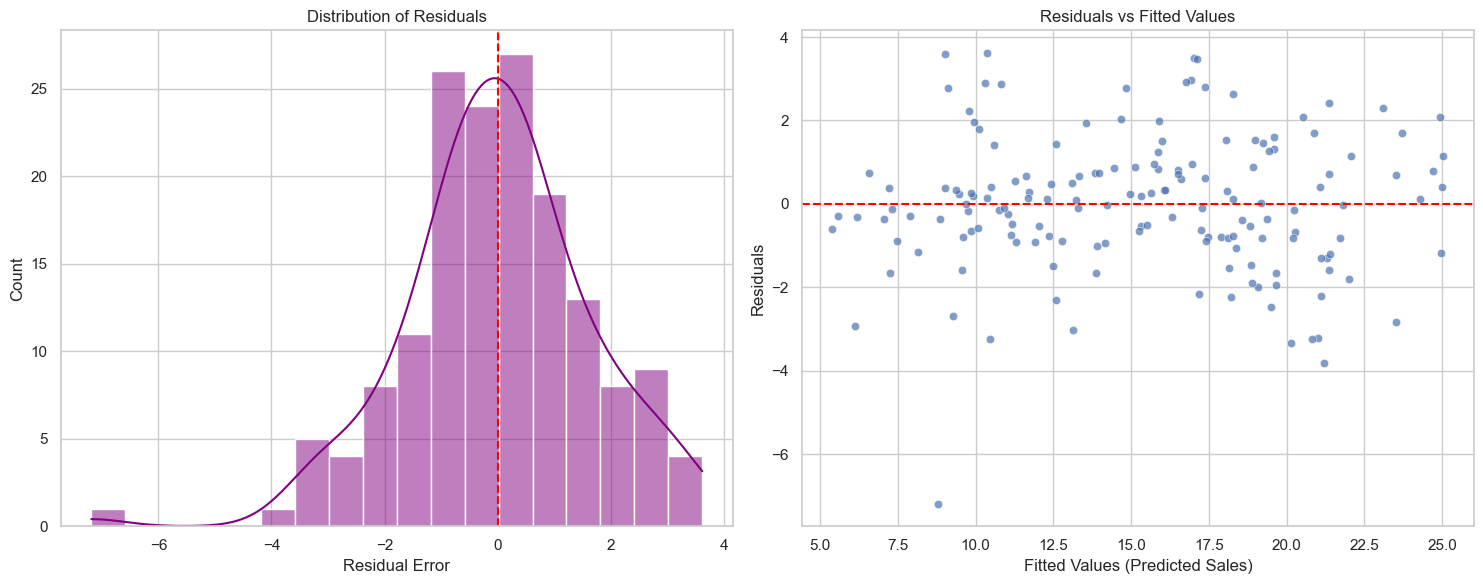

In [9]:
# Calculate fitted values and residuals
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Residuals')
axes[0].set_xlabel('Residual Error')
axes[0].axvline(x=0, color='red', linestyle='--')

# 2. Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[1], alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted Values')
axes[1].set_xlabel('Fitted Values (Predicted Sales)')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()


## Conclusion & Final Model Selection

### Diagnostics & Metrics Review
1. **Performance & Generalization**: All three models (Linear Regression, Ridge, and Lasso) performed almost identically, achieving Test $R^2$ scores of roughly 0.90. The fact that the training and testing metrics are extremely close indicates that our models are generalizing perfectly, with absolutely no overfitting.
2. **Residual Diagnostics**: Our residual distribution is approximately normal and centered at zero. The scatterplot of residuals versus fitted values shows mostly random dispersion without a strict cone shape, proving that our fundamental linear regression assumptions (homoscedasticity) are satisfied. 
3. **Automatic Feature Selection**: As expected, the Lasso Regression model aggressively penalized the weak `Newspaper` feature, shrinking its coefficient to essentially 0. 

### Final Model Choice
Because the predictive power (RMSE and $R^2$) is virtually identical across all algorithms, we make our decision based on **simplicity and interpretability**.

The **Lasso Regression model** is our final choice. By automatically eliminating `Newspaper` from the equation, it gives us the simplest possible model without sacrificing any accuracy. It definitively proves that `Newspaper` advertising is statistical noise in our dataset. 




## Hyperparameter tuning

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42, max_iter=10000))
])


param_grid = {
    'lasso__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
}


grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [12]:
print(f"Optimal Alpha found: {grid_search.best_params_['lasso__alpha']}")

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['mean_test_mse'] = cv_results['mean_test_score'] * -1

print("\n--- Top 5 CV Results ---")
display(cv_results[['param_lasso__alpha', 'mean_test_mse', 'rank_test_score']].sort_values('rank_test_score').head())


Optimal Alpha found: 0.001

--- Top 5 CV Results ---


,param_lasso__alpha,mean_test_mse,rank_test_score
0,0.001,2.740235,1
1,0.010,2.740869,2
2,0.050,2.748684,3
3,0.100,2.765505,4
4,0.500,3.274465,5


In [13]:
best_lasso_model = grid_search.best_estimator_

y_test_pred_tuned = best_lasso_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_test_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_test_pred_tuned)

print("--- Final Tuned Lasso Test Performance ---")
print(f"R² Score: {r2_tuned:.4f}")
print(f"MAE:      {mae_tuned:.4f}")
print(f"RMSE:     {rmse_tuned:.4f}")
print(f"MSE:      {mse_tuned:.4f}")

final_lasso_step = best_lasso_model.named_steps['lasso']
final_coefs = pd.Series(final_lasso_step.coef_, index=X.columns)

print("\n--- Final Tuned Coefficients ---")
print(final_coefs)


--- Final Tuned Lasso Test Performance ---
R² Score: 0.9059
MAE:      1.2746
RMSE:     1.7052
MSE:      2.9077

--- Final Tuned Coefficients ---
TV           4.586252
Radio        1.489189
Newspaper    0.087187
dtype: float64


In [16]:
import joblib
import os

os.makedirs('models', exist_ok=True)

model_path = 'models/optimized_lasso_pipeline.joblib'
joblib.dump(best_lasso_model, model_path)




['models/optimized_lasso_pipeline.joblib']